# Desafio Final — Análise de Dados de Energia com API Pública

**Curso:** Ciência da Computação  
**Disciplina:** Soluções em Energias Renováveis e Sustentáveis

## Situação-problema

Uma equipe de planejamento energético precisa analisar o comportamento da carga elétrica de uma região atendida pelo Sistema Interligado Nacional (SIN).

Os dados serão obtidos diretamente da API pública do Operador Nacional do Sistema Elétrico (ONS). Todos os códigos, resultados, gráficos e respostas permanecerão neste notebook.

## 1. Fonte dos dados

API pública de **Carga Verificada do ONS**:

- Portal: https://dados.ons.org.br/
- Conjunto: https://dados.ons.org.br/dataset/carga-energia-verificada
- Área analisada: SP — São Paulo
- Período: 01/08/2025 a 07/08/2025

## 2. Bibliotecas

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

## 3. Consulta à API

A célula consulta a API do ONS e interrompe a execução com uma mensagem clara caso a solicitação não seja concluída.

In [2]:
url = 'https://apicarga.ons.org.br/prd/cargaverificada'

parametros = {
    'dat_inicio': '2025-08-01',
    'dat_fim': '2025-08-07',
    'cod_areacarga': 'SP'
}

response = requests.get(url, params=parametros, timeout=30)

print('Status:', response.status_code)
print('URL:', response.url)

response.raise_for_status()
dados_json = response.json()

Status: 200
URL: https://apicarga.ons.org.br/prd/cargaverificada?dat_inicio=2025-08-01&dat_fim=2025-08-07&cod_areacarga=SP


## 4. Preparação inicial do JSON

In [3]:
if isinstance(dados_json, list):
    registros = dados_json

elif isinstance(dados_json, dict):
    chaves_com_lista = [
        chave for chave, valor in dados_json.items()
        if isinstance(valor, list)
    ]

    if not chaves_com_lista:
        raise ValueError('A resposta não contém uma lista de registros.')

    chave_registros = chaves_com_lista[0]
    registros = dados_json[chave_registros]
    print('Chave utilizada:', chave_registros)

else:
    raise TypeError('Formato de JSON não reconhecido.')

print('Tipo:', type(registros))
print('Quantidade de registros:', len(registros))

if registros:
    print('\nPrimeiro registro:')
    print(registros[0])

Tipo: <class 'list'>
Quantidade de registros: 336

Primeiro registro:
{'cod_areacarga': 'SP', 'din_atualizacao': '2026-08-14T05:58:29.574Z', 'dat_referencia': '2025-08-01', 'din_referenciautc': '2025-08-01T03:30:00.000Z', 'val_cargaglobal': 15913.618, 'val_cargaglobalcons': 15913.618, 'val_cargaglobalsmmgd': 15892.488, 'val_cargasupervisionada': 14421.112, 'val_carganaosupervisionada': 1471.3759, 'val_cargammgd': 21.13, 'val_consistencia': 0}


# DESAFIO 1 — Construção e inspeção do DataFrame

1. Criar o DataFrame dados.
2. Exibir os primeiros registros.
3. Determinar linhas e colunas.
4. Listar os atributos.
5. Utilizar info().
6. Utilizar describe().
7. Identificar data/hora, área e carga.

In [4]:
dados = pd.DataFrame(registros)

display(dados.head())

print(f'Quantidade de linhas: {dados.shape[0]}')
print(f'Quantidade de colunas: {dados.shape[1]}')
print('\nAtributos:')
print(dados.columns.tolist())

print('\nInformações do DataFrame:')
dados.info()

print('\nEstatísticas descritivas:')
display(dados.describe(include='all'))

,cod_areacarga,din_atualizacao,dat_referencia,din_referenciautc,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
0,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T03:30:00.000Z,15913.618,15913.618,15892.488,14421.112,1471.3759,21.13,0
1,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:00:00.000Z,15251.414,15251.414,15230.284,13758.101,1472.1840,21.13,0
2,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:30:00.000Z,14606.733,14606.733,14585.604,13112.602,1473.0022,21.13,0
3,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:00:00.000Z,14182.290,14182.290,14161.160,12687.433,1473.7275,21.13,0
4,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:30:00.000Z,13838.488,13838.488,13817.358,12342.648,1474.7096,21.13,0


Quantidade de linhas: 336
Quantidade de colunas: 11

Atributos:
['cod_areacarga', 'din_atualizacao', 'dat_referencia', 'din_referenciautc', 'val_cargaglobal', 'val_cargaglobalcons', 'val_cargaglobalsmmgd', 'val_cargasupervisionada', 'val_carganaosupervisionada', 'val_cargammgd', 'val_consistencia']

Informações do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cod_areacarga               336 non-null    object 
 1   din_atualizacao             336 non-null    object 
 2   dat_referencia              336 non-null    object 
 3   din_referenciautc           336 non-null    object 
 4   val_cargaglobal             336 non-null    float64
 5   val_cargaglobalcons         336 non-null    float64
 6   val_cargaglobalsmmgd        336 non-null    float64
 7   val_cargasupervisionada     336 non-null    float6

,cod_areacarga,din_atualizacao,dat_referencia,din_referenciautc,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
count,336,336,336,336,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.0
unique,1,7,7,336,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-07T19:00:00.000Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,336,48,48,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,17870.828981,17870.828981,16953.421626,15495.799695,1457.621862,917.407249,0.0
std,NaN,NaN,NaN,NaN,3029.042438,3029.042438,2962.721503,2982.650359,34.888571,1253.581141,0.0
min,NaN,NaN,NaN,NaN,12139.253000,12139.253000,11549.664000,10054.455000,1391.990800,21.130000,0.0
25%,NaN,NaN,NaN,NaN,15110.533375,15110.533375,14457.604250,12990.878500,1433.112575,21.130000,0.0
50%,NaN,NaN,NaN,NaN,18199.128500,18199.128500,17045.260000,15611.629500,1453.981650,21.196900,0.0
75%,NaN,NaN,NaN,NaN,20386.629500,20386.629500,18931.679500,17502.643500,1479.430775,1793.579475,0.0


### Identificação dos atributos

- **Data de referência:** dat_referencia.
- **Data e horário:** din_referenciautc, registrado pela API em UTC.
- **Área de carga:** cod_areacarga.
- **Valor utilizado na análise:** val_cargaglobal, que representa a carga global verificada.

## DESAFIO 2 — Organização dos dados

Os atributos principais serão renomeados, convertidos e reunidos em um DataFrame específico para a análise.

In [5]:
mapa_colunas = {
    'cod_areacarga': 'Area',
    'dat_referencia': 'Data',
    'din_referenciautc': 'Data_Hora',
    'val_cargaglobal': 'Carga_MW'
}

dados_analise = dados[list(mapa_colunas)].rename(columns=mapa_colunas).copy()

# Conversões explícitas
dados_analise['Data'] = pd.to_datetime(
    dados_analise['Data'],
    errors='coerce'
)

dados_analise['Data_Hora'] = (
    pd.to_datetime(dados_analise['Data_Hora'], errors='coerce', utc=True)
    .dt.tz_convert('America/Sao_Paulo')
)

dados_analise['Carga_MW'] = pd.to_numeric(
    dados_analise['Carga_MW'],
    errors='coerce'
)

print('Tipos após a conversão:')
print(dados_analise.dtypes)

print('\nValores ausentes por atributo:')
ausentes = dados_analise.isna().sum()
print(ausentes)

linhas_antes = len(dados_analise)
dados_analise = dados_analise.dropna(
    subset=['Area', 'Data', 'Data_Hora', 'Carga_MW']
).sort_values('Data_Hora').reset_index(drop=True)
linhas_removidas = linhas_antes - len(dados_analise)

print(f'\nLinhas removidas por ausência em atributos essenciais: {linhas_removidas}')
display(dados_analise.head())

Tipos após a conversão:
Area                                    object
Data                            datetime64[ns]
Data_Hora    datetime64[ns, America/Sao_Paulo]
Carga_MW                               float64
dtype: object

Valores ausentes por atributo:
Area         0
Data         0
Data_Hora    0
Carga_MW     0
dtype: int64

Linhas removidas por ausência em atributos essenciais: 0


,Area,Data,Data_Hora,Carga_MW
0,SP,2025-08-01,2025-08-01 00:30:00-03:00,15913.618
1,SP,2025-08-01,2025-08-01 01:00:00-03:00,15251.414
2,SP,2025-08-01,2025-08-01 01:30:00-03:00,14606.733
3,SP,2025-08-01,2025-08-01 02:00:00-03:00,14182.290
4,SP,2025-08-01,2025-08-01 02:30:00-03:00,13838.488


### Decisão de tratamento

Foram mantidos somente área, data, data/hora e carga global. A carga foi convertida para número; a data foi convertida para formato de data; e o horário UTC foi convertido para o fuso America/Sao_Paulo. Linhas com ausência em algum atributo essencial são removidas, e a quantidade removida é informada explicitamente.

## DESAFIO 3 — Indicadores da carga elétrica

In [6]:
carga_minima = dados_analise['Carga_MW'].min()
carga_maxima = dados_analise['Carga_MW'].max()
carga_media = dados_analise['Carga_MW'].mean()
carga_mediana = dados_analise['Carga_MW'].median()
amplitude_carga = carga_maxima - carga_minima
quantidade_medicoes = len(dados_analise)
diferenca_max_media = carga_maxima - carga_media
diferenca_max_media_pct = diferenca_max_media / carga_media * 100

indicadores = pd.Series({
    'Carga mínima (MW)': carga_minima,
    'Carga máxima (MW)': carga_maxima,
    'Carga média (MW)': carga_media,
    'Mediana (MW)': carga_mediana,
    'Amplitude (MW)': amplitude_carga,
    'Quantidade de medições': quantidade_medicoes
})

display(indicadores.to_frame('Valor'))

display(Markdown(f'''
**Resposta interpretativa:** a carga máxima ficou **{diferenca_max_media:.2f} MW**, ou **{diferenca_max_media_pct:.2f}%**, acima da média. A comparação quantitativa mostra a distância do pico em relação ao comportamento médio; o máximo representa um episódio extremo do período e não o nível típico, que é melhor representado conjuntamente pela média de **{carga_media:.2f} MW** e pela mediana de **{carga_mediana:.2f} MW**.
'''))

,Valor
Carga mínima (MW),12139.253000
Carga máxima (MW),23185.312000
Carga média (MW),17870.828981
Mediana (MW),18199.128500
Amplitude (MW),11046.059000
Quantidade de medições,336.000000



**Resposta interpretativa:** a carga máxima ficou **5314.48 MW**, ou **29.74%**, acima da média. A comparação quantitativa mostra a distância do pico em relação ao comportamento médio; o máximo representa um episódio extremo do período e não o nível típico, que é melhor representado conjuntamente pela média de **17870.83 MW** e pela mediana de **18199.13 MW**.


## DESAFIO 4 — Períodos de alta demanda

In [7]:
limiar_alta_demanda = 0.90 * carga_maxima

alta_demanda = dados_analise[
    dados_analise['Carga_MW'] > limiar_alta_demanda
].copy()

quantidade_alta_demanda = len(alta_demanda)
percentual_alta_demanda = (
    quantidade_alta_demanda / quantidade_medicoes * 100
)

indice_pico = dados_analise['Carga_MW'].idxmax()
registro_pico = dados_analise.loc[indice_pico]
momento_pico = registro_pico['Data_Hora']
valor_pico = registro_pico['Carga_MW']

print(f'Limiar de alta demanda: {limiar_alta_demanda:.2f} MW')
print(f'Quantidade de registros: {quantidade_alta_demanda}')
print(f'Percentual: {percentual_alta_demanda:.2f}%')
print(f'Maior carga: {valor_pico:.2f} MW')
print(f'Momento do pico: {momento_pico:%d/%m/%Y %H:%M %Z}')

display(alta_demanda.head())

Limiar de alta demanda: 20866.78 MW
Quantidade de registros: 50
Percentual: 14.88%
Maior carga: 23185.31 MW
Momento do pico: 01/08/2025 19:00 -03


,Area,Data,Data_Hora,Carga_MW
35,SP,2025-08-01,2025-08-01 18:00:00-03:00,21088.959
36,SP,2025-08-01,2025-08-01 18:30:00-03:00,22398.360
37,SP,2025-08-01,2025-08-01 19:00:00-03:00,23185.312
38,SP,2025-08-01,2025-08-01 19:30:00-03:00,22903.314
39,SP,2025-08-01,2025-08-01 20:00:00-03:00,22358.701


In [9]:
classificacao_parcela = (
    'pequena' if percentual_alta_demanda < 20 else 'relevante'
)

display(Markdown(f'''
Os registros acima de 90% do máximo representam **{percentual_alta_demanda:.2f}%** das medições. Pelo critério adotado, essa é uma parcela **{classificacao_parcela}** do período analisado. Portanto, os valores próximos ao pico não representam o comportamento predominante de toda a semana.
'''))


Os registros acima de 90% do máximo representam **14.88%** das medições. Pelo critério adotado, essa é uma parcela **pequena** do período analisado. Portanto, os valores próximos ao pico não representam o comportamento predominante de toda a semana.


## DESAFIO 5 — Segundo critério de análise

**Critério escolhido:** carga acima da média semanal. Esse recorte permite comparar um conjunto amplo de valores superiores ao comportamento médio com o conjunto mais restritivo de alta demanda.

In [10]:
acima_da_media = dados_analise[
    dados_analise['Carga_MW'] > carga_media
].copy()

quantidade_acima_media = len(acima_da_media)
percentual_acima_media = (
    quantidade_acima_media / quantidade_medicoes * 100
)

intersecao_criterios = dados_analise[
    (dados_analise['Carga_MW'] > carga_media) &
    (dados_analise['Carga_MW'] > limiar_alta_demanda)
].copy()

print(f'Critério: carga acima da média de {carga_media:.2f} MW')
print(f'Quantidade: {quantidade_acima_media}')
print(f'Percentual: {percentual_acima_media:.2f}%')
print(f'Registros que também são de alta demanda: {len(intersecao_criterios)}')

display(acima_da_media.head())

Critério: carga acima da média de 17870.83 MW
Quantidade: 184
Percentual: 54.76%
Registros que também são de alta demanda: 50


,Area,Data,Data_Hora,Carga_MW
15,SP,2025-08-01,2025-08-01 08:00:00-03:00,18096.023
16,SP,2025-08-01,2025-08-01 08:30:00-03:00,18629.395
17,SP,2025-08-01,2025-08-01 09:00:00-03:00,18825.176
18,SP,2025-08-01,2025-08-01 09:30:00-03:00,19056.504
19,SP,2025-08-01,2025-08-01 10:00:00-03:00,19427.822


In [11]:
display(Markdown(f'''
**Comparação:** o recorte de carga acima da média contém **{quantidade_acima_media} registros ({percentual_acima_media:.2f}%)**, enquanto o recorte de alta demanda contém **{quantidade_alta_demanda} registros ({percentual_alta_demanda:.2f}%)**. O segundo critério é mais abrangente porque exige apenas superar a média, enquanto a alta demanda exige superar 90% do maior valor observado.
'''))


**Comparação:** o recorte de carga acima da média contém **184 registros (54.76%)**, enquanto o recorte de alta demanda contém **50 registros (14.88%)**. O segundo critério é mais abrangente porque exige apenas superar a média, enquanto a alta demanda exige superar 90% do maior valor observado.


## DESAFIO 6 — Visualização

### Gráfico 1 — Carga ao longo do tempo

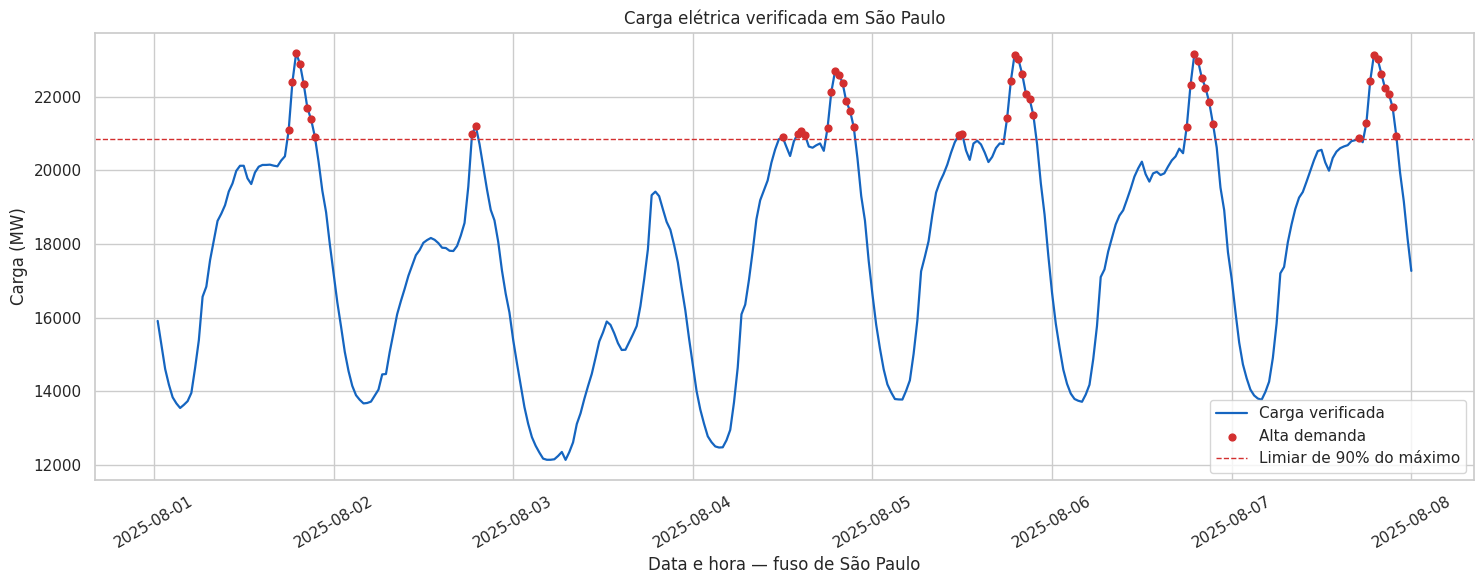

In [12]:
plt.figure(figsize=(15, 6))

sns.lineplot(
    data=dados_analise,
    x='Data_Hora',
    y='Carga_MW',
    color='#1565C0',
    linewidth=1.6,
    label='Carga verificada'
)

plt.scatter(
    alta_demanda['Data_Hora'],
    alta_demanda['Carga_MW'],
    color='#D32F2F',
    s=24,
    label='Alta demanda',
    zorder=3
)

plt.axhline(
    limiar_alta_demanda,
    color='#D32F2F',
    linestyle='--',
    linewidth=1,
    label='Limiar de 90% do máximo'
)

plt.title('Carga elétrica verificada em São Paulo')
plt.xlabel('Data e hora — fuso de São Paulo')
plt.ylabel('Carga (MW)')
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [13]:
momento_minimo = dados_analise.loc[
    dados_analise['Carga_MW'].idxmin(), 'Data_Hora'
]

display(Markdown(f'''
**Interpretação do gráfico 1:** a série mostra variações da carga durante a semana e permite localizar os períodos destacados acima do limiar. O pico foi de **{valor_pico:.2f} MW**, em **{momento_pico:%d/%m/%Y às %H:%M}**, enquanto o mínimo ocorreu em **{momento_minimo:%d/%m/%Y às %H:%M}**. O gráfico evidencia recorrência temporal, mas não permite atribuir causas sem variáveis adicionais.
'''))


**Interpretação do gráfico 1:** a série mostra variações da carga durante a semana e permite localizar os períodos destacados acima do limiar. O pico foi de **23185.31 MW**, em **01/08/2025 às 19:00**, enquanto o mínimo ocorreu em **03/08/2025 às 07:00**. O gráfico evidencia recorrência temporal, mas não permite atribuir causas sem variáveis adicionais.


### Gráfico 2 — Carga média diária

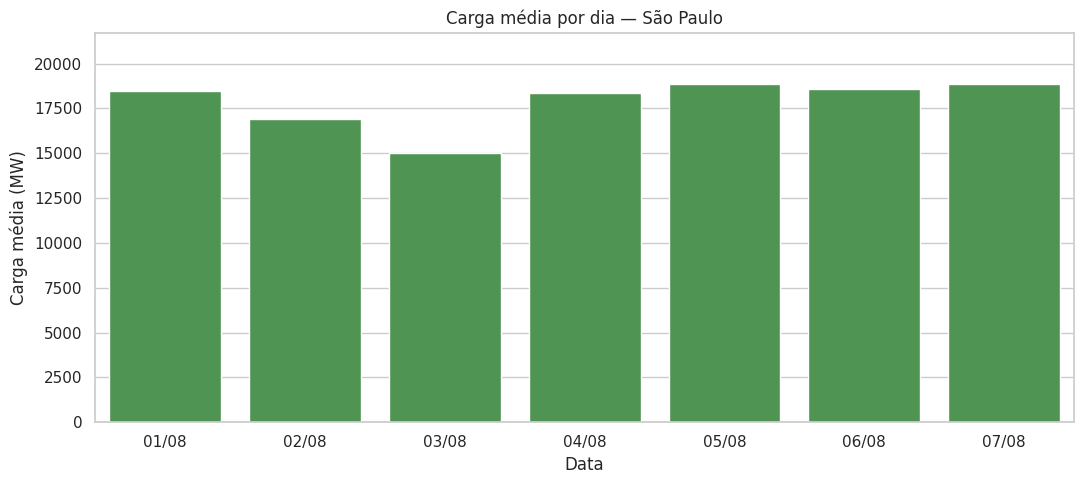

In [14]:
media_diaria = (
    dados_analise
    .groupby('Data', as_index=False)['Carga_MW']
    .mean()
)

media_diaria['Dia'] = media_diaria['Data'].dt.strftime('%d/%m')

plt.figure(figsize=(11, 5))
sns.barplot(
    data=media_diaria,
    x='Dia',
    y='Carga_MW',
    color='#43A047'
)

plt.title('Carga média por dia — São Paulo')
plt.xlabel('Data')
plt.ylabel('Carga média (MW)')
plt.ylim(0, media_diaria['Carga_MW'].max() * 1.15)
plt.tight_layout()
plt.show()

In [15]:
dia_maior_media = media_diaria.loc[media_diaria['Carga_MW'].idxmax()]
dia_menor_media = media_diaria.loc[media_diaria['Carga_MW'].idxmin()]

display(Markdown(f'''
**Interpretação do gráfico 2:** a maior média diária ocorreu em **{dia_maior_media["Data"]:%d/%m/%Y}**, com **{dia_maior_media["Carga_MW"]:.2f} MW**. A menor ocorreu em **{dia_menor_media["Data"]:%d/%m/%Y}**, com **{dia_menor_media["Carga_MW"]:.2f} MW**. A comparação resume diferenças entre os dias, sem explicar suas causas.
'''))


**Interpretação do gráfico 2:** a maior média diária ocorreu em **05/08/2025**, com **18882.60 MW**. A menor ocorreu em **03/08/2025**, com **15036.06 MW**. A comparação resume diferenças entre os dias, sem explicar suas causas.


## DESAFIO 7 — Síntese para o relatório

In [16]:
regiao = ', '.join(dados_analise['Area'].astype(str).unique())
inicio_periodo = dados_analise['Data_Hora'].min()
fim_periodo = dados_analise['Data_Hora'].max()

resumo_resultados = f'''
Região analisada: {regiao} — São Paulo
Período analisado: {inicio_periodo:%d/%m/%Y %H:%M} a {fim_periodo:%d/%m/%Y %H:%M}, horário de São Paulo
Quantidade de registros: {quantidade_medicoes}
Carga mínima: {carga_minima:.2f} MW
Carga máxima: {carga_maxima:.2f} MW
Carga média: {carga_media:.2f} MW
Mediana: {carga_mediana:.2f} MW
Amplitude: {amplitude_carga:.2f} MW
Limiar de alta demanda: {limiar_alta_demanda:.2f} MW
Registros de alta demanda: {quantidade_alta_demanda}
Percentual de alta demanda: {percentual_alta_demanda:.2f}%
Momento do pico: {momento_pico:%d/%m/%Y %H:%M}, horário de São Paulo
Segundo critério: carga acima da média
Resultado do segundo critério: {quantidade_acima_media} registros, equivalentes a {percentual_acima_media:.2f}%
'''

print(resumo_resultados)


Região analisada: SP — São Paulo
Período analisado: 01/08/2025 00:30 a 08/08/2025 00:00, horário de São Paulo
Quantidade de registros: 336
Carga mínima: 12139.25 MW
Carga máxima: 23185.31 MW
Carga média: 17870.83 MW
Mediana: 18199.13 MW
Amplitude: 11046.06 MW
Limiar de alta demanda: 20866.78 MW
Registros de alta demanda: 50
Percentual de alta demanda: 14.88%
Momento do pico: 01/08/2025 19:00, horário de São Paulo
Segundo critério: carga acima da média
Resultado do segundo critério: 184 registros, equivalentes a 54.76%



# OPCIONAL — Relatório técnico com apoio do Gemini

No Colab, crie o secret GEMINI_API_KEY e permita que o notebook tenha acesso a ele. A chave não deve ser escrita diretamente no código.

In [17]:
!pip -q install -U google-genai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 14.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.57.0 which is incompatible.


In [20]:
from google.colab import userdata
from google import genai

try:
    GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')
except Exception:
    GEMINI_API_KEY = None

if GEMINI_API_KEY:
    client = genai.Client(api_key=GEMINI_API_KEY)
    print('Cliente Gemini configurado.')
else:
    print('Secret GEMINI_API_KEY não encontrado. A etapa opcional será ignorada.')

Cliente Gemini configurado.


## DESAFIO 8 — Geração do relatório

In [21]:
prompt = f'''
Atue como analista de dados do setor elétrico.

Produza um relatório técnico curto com base EXCLUSIVAMENTE nos resultados abaixo.

Não invente causas para as variações observadas.
Não apresente como fato explicações que não possam ser sustentadas pelos dados.
Diferencie claramente resultados observados de hipóteses.

Inclua:
1. caracterização do conjunto analisado;
2. principais indicadores;
3. análise dos períodos de alta demanda;
4. comparação com o segundo critério;
5. conclusão.

RESULTADOS DA EQUIPE:

{resumo_resultados}
'''

In [22]:
if GEMINI_API_KEY:
    response_gemini = client.models.generate_content(
        model='gemini-3.6-flash',
        contents=prompt
    )
    relatorio_gemini = response_gemini.text
    print(relatorio_gemini)
else:
    relatorio_gemini = ''
    print('Relatório Gemini não gerado: configure o secret e execute novamente.')

**RELATÓRIO TÉCNICO DE ANÁLISE DE CARGA ELÉTRICA**

---

### 1. Caracterização do Conjunto Analisado
* **Região:** São Paulo (SP)
* **Período de amostragem:** 01/08/2025 às 00:30 a 08/08/2025 às 00:00 (horário de São Paulo)
* **Total de registros:** 336 medições

---

### 2. Principais Indicadores
Com base na totalidade dos 336 registros do período, foram observados os seguintes parâmetros quantitativos de carga:

* **Carga Mínima:** 12.139,25 MW
* **Carga Máxima (Pico):** 23.185,31 MW
* **Carga Média:** 17.870,83 MW
* **Mediana:** 18.199,13 MW
* **Amplitude:** 11.046,06 MW

---

### 3. Análise dos Períodos de Alta Demanda
* **Limiar estabelecido:** 20.866,78 MW
* **Ocorrências:** 50 registros
* **Proporção do período:** 14,88% do total analisado
* **Momento do pico máximo:** 01/08/2025 às 19:00

**Observação e Diferenciação:**
* *Resultado Observado:* A variação total do sistema (amplitude) no período foi de 11.046,06 MW, e os eventos de alta demanda (superiores a 20.866,78 MW) repres

## DESAFIO 9 — Validação crítica

A validação humana continua necessária mesmo quando o relatório é produzido com apoio de IA.

In [23]:
validacao_critica = f'''
1. Os indicadores da versão final foram conferidos com as variáveis calculadas no notebook: mínimo, máximo, média, mediana, limiar, quantidade, percentual e momento do pico.

2. A versão final não afirma causas para as variações, pois a API consultada fornece valores de carga, mas não traz variáveis suficientes para explicar os motivos das mudanças.

3. Foram evitadas interpretações exageradas e relações causais. Os textos descrevem diferenças, frequências e coincidências observadas.

4. Na revisão, foram mantidas as unidades em MW, incluído o fuso horário de São Paulo, substituídas expressões vagas por valores calculados e separadas observações de possíveis hipóteses.
'''

print(validacao_critica)


1. Os indicadores da versão final foram conferidos com as variáveis calculadas no notebook: mínimo, máximo, média, mediana, limiar, quantidade, percentual e momento do pico.

2. A versão final não afirma causas para as variações, pois a API consultada fornece valores de carga, mas não traz variáveis suficientes para explicar os motivos das mudanças.

3. Foram evitadas interpretações exageradas e relações causais. Os textos descrevem diferenças, frequências e coincidências observadas.

4. Na revisão, foram mantidas as unidades em MW, incluído o fuso horário de São Paulo, substituídas expressões vagas por valores calculados e separadas observações de possíveis hipóteses.



## Relatório final revisado

In [24]:
relatorio_final = f'''
# Relatório técnico — Carga elétrica verificada em São Paulo

## Caracterização

Foram analisadas **{quantidade_medicoes} medições** da área de carga **{regiao} — São Paulo**, entre **{inicio_periodo:%d/%m/%Y %H:%M}** e **{fim_periodo:%d/%m/%Y %H:%M}**, no horário de São Paulo. Os registros foram obtidos da API pública do ONS.

## Indicadores

A carga variou de **{carga_minima:.2f} MW** a **{carga_maxima:.2f} MW**, resultando em amplitude de **{amplitude_carga:.2f} MW**. A média foi de **{carga_media:.2f} MW** e a mediana de **{carga_mediana:.2f} MW**. O máximo ficou **{diferenca_max_media_pct:.2f}%** acima da média.

## Alta demanda

O limiar de alta demanda, definido como 90% do máximo, foi de **{limiar_alta_demanda:.2f} MW**. Foram identificados **{quantidade_alta_demanda} registros**, correspondentes a **{percentual_alta_demanda:.2f}%** das medições. O pico de **{valor_pico:.2f} MW** ocorreu em **{momento_pico:%d/%m/%Y às %H:%M}**.

## Segundo critério

O segundo recorte considerou carga acima da média. Ele reuniu **{quantidade_acima_media} registros ({percentual_acima_media:.2f}%)**. Esse conjunto é mais amplo que o de alta demanda porque utiliza um limite menos restritivo.

## Conclusão

A análise identificou a faixa de variação da carga, o momento do pico e a frequência dos registros próximos ao máximo. Os resultados descrevem o comportamento observado no período. Como o conjunto consultado não reúne fatores explicativos, não é possível atribuir causas às variações apenas com estes dados.
'''

display(Markdown(relatorio_final))


# Relatório técnico — Carga elétrica verificada em São Paulo

## Caracterização

Foram analisadas **336 medições** da área de carga **SP — São Paulo**, entre **01/08/2025 00:30** e **08/08/2025 00:00**, no horário de São Paulo. Os registros foram obtidos da API pública do ONS.

## Indicadores

A carga variou de **12139.25 MW** a **23185.31 MW**, resultando em amplitude de **11046.06 MW**. A média foi de **17870.83 MW** e a mediana de **18199.13 MW**. O máximo ficou **29.74%** acima da média.

## Alta demanda

O limiar de alta demanda, definido como 90% do máximo, foi de **20866.78 MW**. Foram identificados **50 registros**, correspondentes a **14.88%** das medições. O pico de **23185.31 MW** ocorreu em **01/08/2025 às 19:00**.

## Segundo critério

O segundo recorte considerou carga acima da média. Ele reuniu **184 registros (54.76%)**. Esse conjunto é mais amplo que o de alta demanda porque utiliza um limite menos restritivo.

## Conclusão

A análise identificou a faixa de variação da carga, o momento do pico e a frequência dos registros próximos ao máximo. Os resultados descrevem o comportamento observado no período. Como o conjunto consultado não reúne fatores explicativos, não é possível atribuir causas às variações apenas com estes dados.
